In [105]:
import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
CSV_PATH = "/content/drive/MyDrive/phishing_project/datasets/Phishing_Email.csv"

In [109]:
import pandas as pd
df = pd.read_csv(CSV_PATH)
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [110]:
df.shape

(18650, 3)

In [111]:
# Randomly sample 5,000 rows from the full dataset
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

print(df.head())

   Unnamed: 0                                         Email Text  \
0       14470  Once upon a time, Harri wrote :> Title page ha...   
1        3014  new books : generative studies we would like t...   
2       16942  new book : japanese linguistics japanese lingu...   
3       14345  renewal notice for your domain name ( s ) dear...   
4        8098  hot stock tip your broker won ' t share now th...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3      Safe Email  
4  Phishing Email  


In [112]:
# remove extra unnamed column if it exists
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# rename text column
df = df.rename(columns={'Email Text': 'text'})

# create label column
df['label'] = df['Email Type'].map({
    'Safe Email': 0,
    'Phishing Email': 1
})

# optional: drop old column
df = df.drop(columns=['Email Type'])

print(df.head())

                                                text  label
0  Once upon a time, Harri wrote :> Title page ha...      0
1  new books : generative studies we would like t...      0
2  new book : japanese linguistics japanese lingu...      0
3  renewal notice for your domain name ( s ) dear...      0
4  hot stock tip your broker won ' t share now th...      1


In [114]:
# Remove nulls
df.dropna(inplace=True)

# Ensure label is integer
df['label'] = df['label'].astype(int)


In [115]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4997 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4997 non-null   object
 1   label   4997 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 117.1+ KB
None


In [116]:
df.shape

(4997, 2)

In [117]:
df.head()

,text,label
0,"Once upon a time, Harri wrote :> Title page ha...",0
1,new books : generative studies we would like t...,0
2,new book : japanese linguistics japanese lingu...,0
3,renewal notice for your domain name ( s ) dear...,0
4,hot stock tip your broker won ' t share now th...,1


In [118]:
df.tail()

,text,label
4995,"gulf coast pipeline company dyersdale area , h...",0
4996,"re : white wall board anita , no problem . vin...",0
4997,empty,1
4998,fw : priority customer list this is not going ...,0
4999,get ready to s \ ave yourself thousands prefer...,1


Explore the dataset
Plot Class Distribution

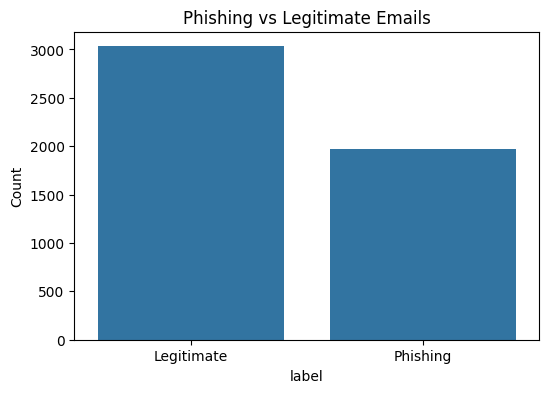

In [119]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()

TF-IDF Text Vectorization

In [120]:

# Step 1: Import required library
# TfidfVectorizer is used to convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 2: Select the correct text column
# This avoids error if column name is 'Email Text' or 'text'
text_col = 'Email Text' if 'Email Text' in df.columns else 'text'

# Step 3: Basic text cleaning
# Convert all values to string and remove extra spaces
df[text_col] = df[text_col].astype(str).str.strip()

# Step 4: Create TF-IDF vectorizer
# max_features=5000 → keep top 5000 important words
# stop_words='english' → remove common words like "the", "is"
# ngram_range=(1,2) → include single words and word pairs (better detection)
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Step 5: Convert email text into numerical vectors (MAIN STEP)
# Each email is transformed into a vector of TF-IDF scores
X_text = tfidf.fit_transform(df[text_col])

# Step 6: Display shape of the result
# Rows = number of emails, Columns = number of features (words)
print("TF-IDF Shape:", X_text.shape)


# =========================================
# DISPLAY TF-IDF VALUES FOR ONE EMAIL
# =========================================

# Step 7: Get all feature (word) names
feature_names = tfidf.get_feature_names_out()

# Step 8: Select one email (example: first email)
email_index = 0

# Step 9: Convert sparse matrix row into array
# This extracts TF-IDF values for that specific email
tfidf_values = X_text[email_index].toarray().flatten()

# Step 10: Create a table (word + value)
import pandas as pd
tfidf_table = pd.DataFrame({
    'word': feature_names,
    'value': tfidf_values
})

# Step 11: Remove words with zero importance
# Only keep words that actually appear in the email
tfidf_table = tfidf_table[tfidf_table['value'] > 0]

# Step 12: Sort words by importance (highest first)
tfidf_table = tfidf_table.sort_values(by='value', ascending=False)

# Step 13: Display top 10 important words
print(tfidf_table.head(10))


TF-IDF Shape: (4997, 5000)
              word     value
539            apt  0.387872
2880      matthias  0.265940
3920      rpm list  0.225518
3919           rpm  0.223674
4535          time  0.171812
2689          list  0.169495
2249      http apt  0.164600
2743         login  0.143694
666      barcelona  0.141938
4579  trade center  0.141108


Email/Text special character Length Distribution by Class

This graph is a boxplot comparing the number of special characters used in legitimate vs phishing emails.

Special characters: ! @ # $ % ^ & * ( ) _ + = { } [ ] : ; " ' < > / ? ,

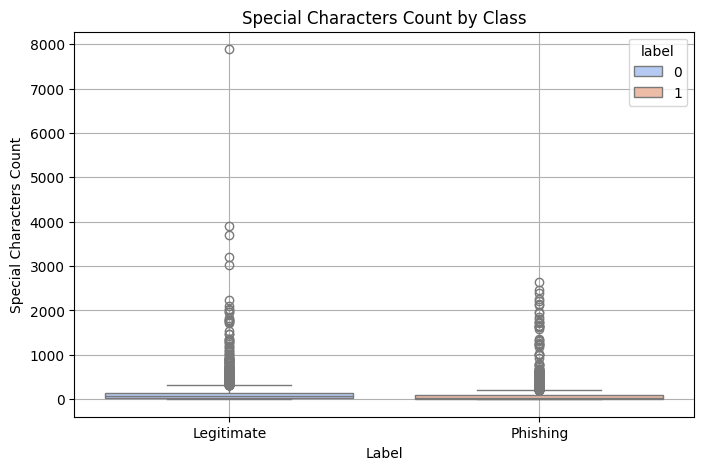

In [121]:
df['special_chars'] = df['text'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

Most Common Words


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


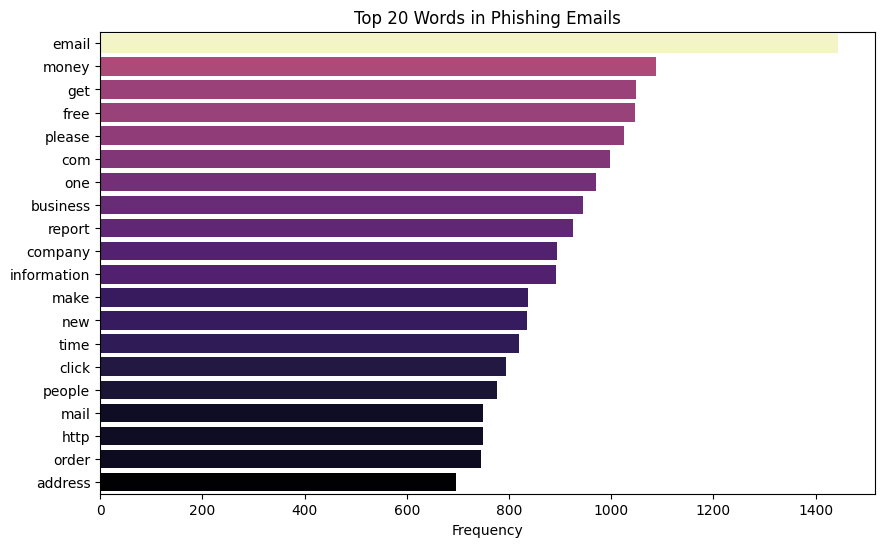

In [122]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [
    word for word in phishing_words
    if word.isalpha() and word not in stop_words and len(word) > 2
]

word_freq = Counter(filtered_words).most_common(20)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

Purpose of Word Cloud

 It is used to visually show the most frequent words in phishing emails

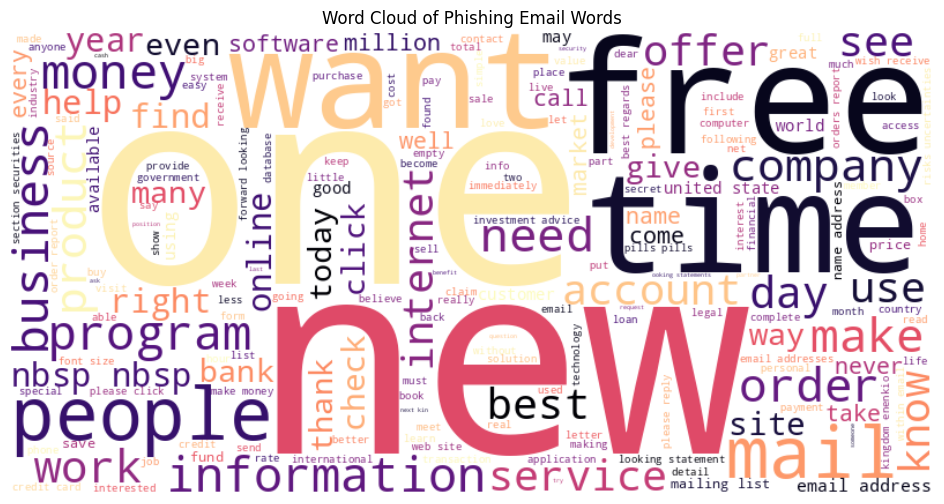

In [123]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()

 Engineer Domain-Specific Features

This step creates new phishing-related features such as text length, word count, URL count, digit count, uppercase letters, special characters, and suspicious keyword count.


In [127]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['text', 'label', 'special_chars', 'text_length', 'word_count',
       'url_count', 'digit_count', 'uppercase_count', 'special_char_count',
       'suspicious_word_count'],
      dtype='object')


In [128]:
df['text'] = df['text'].astype(str)

# Create phishing-related features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['url_count'] = df['text'].apply(lambda x: x.lower().count('http'))
df['digit_count'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))
df['uppercase_count'] = df['text'].apply(lambda x: sum(c.isupper() for c in x))
df['special_char_count'] = df['text'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)

# Suspicious words
suspicious_words = ['urgent', 'verify', 'bank', 'password', 'click', 'login', 'account', 'security', 'limited']

df['suspicious_word_count'] = df['text'].apply(
    lambda x: sum(word in x.lower() for word in suspicious_words)
)

# Show result
df[['text_length', 'word_count', 'url_count', 'digit_count',
    'uppercase_count', 'special_char_count', 'suspicious_word_count']].head()

,text_length,word_count,url_count,digit_count,uppercase_count,special_char_count,suspicious_word_count
0,772,96,2,17,30,97,1
1,2366,491,3,109,0,165,0
2,1155,216,2,53,0,82,0
3,3025,637,3,46,0,137,2
4,8813,1657,0,52,0,253,3


Detect Outliers

This step detects outliers in the text_length feature using the Z-score method


In [ ]:
import numpy as np
from scipy import stats

z_scores = np.abs(stats.zscore(df['text_length'], nan_policy='omit'))

outlier_count = (z_scores > 3).sum()
print("Number of outliers detected in text_length:", outlier_count)

# Show some outliers
outliers = df[z_scores > 3]
print("\nSample outliers:")
print(outliers[['text_length']].head())

Number of outliers detected in text_length: 65

Sample outliers:
     text_length
6          71757
223        22783
260        16242
404        16672
408        16340


Treat Outliers

This cell removes rows where the text length has extreme outlier values

In [ ]:
df = df[z_scores <= 3]

print("Dataset shape after outlier removal:", df.shape)

Dataset shape after outlier removal: (4932, 9)


 Split the Dataset

This step splits the dataset into training (70%), validation (15%), and testing (15%) sets using stratified sampling.



In [129]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3497, 10)
Validation shape: (750, 10)
Test shape: (750, 10)


Tokenization using BERT Tokenizer

Prepares the split dataset by extracting text and labels for use in the BERT model.

Prepare Data for BERT Model

In [130]:
train_texts = train_df['text'].tolist()
val_texts = val_df['text'].tolist()
test_texts = test_df['text'].tolist()

train_labels = train_df['label'].tolist()
val_labels = val_df['label'].tolist()
test_labels = test_df['label'].tolist()



Convert to list

Converts data into list format for model input

the text and labels were converted into list format so they can be used as input for the BERT model.

In [131]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

In [141]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0])

[101, 2097, 2022, 2006, 1996, 2392, 3931, 1997, 8224, 2306, 4466, 2847, 999, 12361, 999, 2115, 2793, 1998, 6350, 2097, 2022, 2006, 1996, 2392, 3931, 1997, 8224, 1999, 2069, 4466, 2847, 2030, 2115, 2769, 2067, 999, 12361, 999, 2004, 5826, 2007, 8224, 1012, 4012, 1998, 1996, 8224, 2897, 2057, 2064, 3749, 2000, 2173, 2115, 4773, 2609, 2006, 1996, 2392, 3931, 2005, 2115, 10328, 999, 2023, 2965, 2008, 2058, 3770, 2454, 2613, 5198, 2860, 6806, 2224, 1996, 8224, 3945, 3194, 5685, 1996, 8224, 2897, 2296, 2154, 2064, 2156, 2115, 2793, 1998, 6350, 4773, 2609, 999, 2035, 2005, 2069, 1069, 6535, 1012, 5345, 2005, 2416, 2706, 2129, 2515, 2009, 2147, 1029, 3071, 2008, 4127, 1999, 2151, 1997, 2122, 2087, 2109, 15672, 2917, 2247, 2007, 2115, 2237, 2030, 2103, 2097, 102]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

Create Dataset for BERT Model
creates a custom dataset class to convert tokenized inputs and labels into a format suitable for training the BERT model using PyTorch

PyTorch: Python library used for machine learning and deep learning.

In [134]:
# Create a custom dataset class for PyTorch
class EmailDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        # Store tokenized inputs (input_ids, attention_mask)
        self.encodings = encodings

        # Store corresponding labels (0 = safe, 1 = phishing)
        self.labels = labels

    def __getitem__(self, idx):
        # Get one sample (input_ids, attention_mask) at index idx
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

        # Add label for that sample
        item['labels'] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        # Return total number of samples in dataset
        return len(self.labels)


# Create training dataset (used to train the model)
train_dataset = EmailDataset(train_encodings, train_labels)

# Create validation dataset (used to evaluate model performance)
val_dataset = EmailDataset(val_encodings, val_labels)

Load Pretrained BERT for Classification

In [135]:
# Load pre-trained BERT model for text classification
# "bert-base-uncased" is used as the base model
# num_labels=2 indicates binary classification (0 = Safe Email, 1 = Phishing Email)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Define evaluation metrics function

This function calculates accuracy, precision, recall, and F1-score to evaluate the model performance.

In [143]:
# Define evaluation metrics function
# This function calculates model performance using accuracy, precision, recall, and F1-score
def compute_metrics(pred):

    # Get true labels from predictions
    labels = pred.label_ids

    # Get predicted labels (choose class with highest probability)
    preds = pred.predictions.argmax(-1)

    # Calculate precision, recall, and F1-score for binary classification
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')

    # Calculate accuracy
    acc = accuracy_score(labels, preds)

    # Return all evaluation metrics as a dictionary
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Training Arguments

This step defines how the BERT model will be trained, including settings like number of epochs, batch size, and learning rate. It helps control the training process but does not train the model itself.

In [137]:
# Define training settings for the BERT model
training_args = TrainingArguments(
    output_dir='./results',            # Folder to save model checkpoints
    eval_strategy="epoch",             # Evaluate model after each epoch
    save_strategy="epoch",             # Save checkpoint after each epoch
    save_total_limit=2,                # Keep only the latest 2 checkpoints
    learning_rate=2e-5,                # Learning rate for fine-tuning BERT
    per_device_train_batch_size=8,    # Training batch size
    per_device_eval_batch_size=8,     # Evaluation batch size
    num_train_epochs=5,                # Number of full training cycles
    weight_decay=0.01,                 # Regularization to reduce overfitting
    optim="adamw_torch",               # Optimizer used for training
    logging_dir='./logs',              # Folder to save training logs
    logging_strategy="epoch",          # Log results after each epoch
    load_best_model_at_end=True,       # Load best model after training ends
    metric_for_best_model="f1",        # Select best model based on F1-score
    greater_is_better=True             # Higher F1-score means better model
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Create Dataset Objects

In [138]:
# Create PyTorch datasets for training and validation
train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)

Trainer

Trainer is the training engine provided by Hugging Face. It handles the full model training lifecycle. Specifically, it:


In [139]:
# Create Trainer object to handle training and evaluation of the model
trainer = Trainer(
    model=model,                          # BERT model for classification
    args=training_args,                   # Training configuration (epochs, batch size, etc.)
    train_dataset=train_dataset,          # Dataset used for training the model
    eval_dataset=val_dataset,             # Dataset used for validation during training
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),  # Handles dynamic padding of input data
    compute_metrics=compute_metrics       # Function to calculate accuracy, precision, recall, and F1-score
)

In [140]:
# Start training the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.289266,0.216618,0.934667,0.911071,0.980469,0.850847
2,0.100054,0.103197,0.973333,0.966555,0.953795,0.979661
3,0.036226,0.184374,0.966667,0.957265,0.965517,0.949153
4,0.027671,0.136002,0.972000,0.964346,0.965986,0.962712
5,0.020559,0.132088,0.972000,0.964103,0.972414,0.955932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2190, training_loss=0.0947549854783707, metrics={'train_runtime': 670.3139, 'train_samples_per_second': 26.085, 'train_steps_per_second': 3.267, 'total_flos': 1150124200742400.0, 'train_loss': 0.0947549854783707, 'epoch': 5.0})

Confusion Matrix

Shows correct and incorrect predictions (Safe vs Phishing)

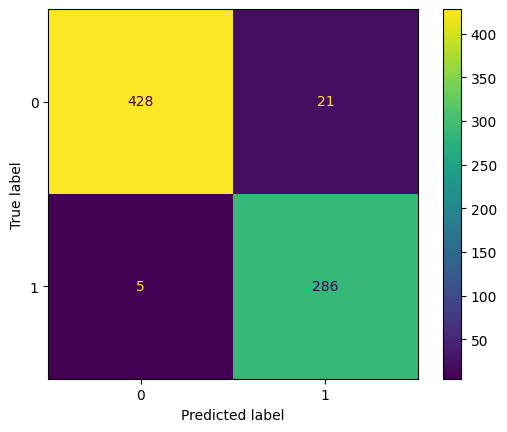

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(val_dataset)

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

AUC (ROC Score)
Measures how well the model separates phishing and safe emails. Higher value = better model

In [ ]:
from sklearn.metrics import roc_auc_score

# Get probabilities
y_probs = predictions.predictions[:, 1]

auc = roc_auc_score(y_true, y_probs)
print("AUC Score:", auc)

AUC Score: 0.9964755585149129


In [144]:
model.save_pretrained("phishing_model")
tokenizer.save_pretrained("phishing_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('phishing_model/tokenizer_config.json', 'phishing_model/tokenizer.json')

Phishing Email Detector Web Application

creates a web-based interface using Gradio where users can input an email and get a prediction of whether it is phishing or safe. The trained BERT model is used to classify the email in real time

In [ ]:
import torch
import gradio as gr

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def predict(email):
    inputs = tokenizer(email, return_tensors="pt", truncation=True, padding=True).to(device)
    outputs = model(**inputs)
    pred = outputs.logits.argmax().item()
    return "🚨 Phishing Email" if pred == 1 else "✅ Safe Email"

iface = gr.Interface(fn=predict, inputs="text", outputs="text")
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a5ca3dfcea3e0adca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Check GPU Availability

In [145]:
import torch
print(torch.cuda.is_available())

True


remove all output cells from the notebook to make it clean, reduce file size, and prepare it for submission

In [ ]:
!pip install nbconvert
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace phishingdetectorBert.ipynb

[NbConvertApp] WARNING | pattern 'phishingdetectorBert.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex

In [146]:
!ls
!pwd
!find / -maxdepth 3 -name "*.ipynb" 2>/dev/null

drive  phishing_model  results	sample_data
/content


In [147]:
notebook_path = "phisingdetectorBert.ipynb"

In [148]:
import json

# Save current notebook first
from google.colab import _message
nb = _message.blocking_request('get_ipynb')['ipynb']

# Remove widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Save clean file
with open("clean_notebook.ipynb", "w") as f:
    json.dump(nb, f)

print("Clean notebook saved")

Clean notebook saved


In [149]:
import os
print(os.path.exists("/content/phishing_model"))
print(os.listdir("/content"))

True
['.config', '.gradio', 'results', 'clean_notebook.ipynb', 'phishing_model', 'drive', 'sample_data']


In [150]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [151]:
!zip -r phishing_model.zip /content/phishing_model

  adding: content/phishing_model/ (stored 0%)
  adding: content/phishing_model/model.safetensors (deflated 7%)
  adding: content/phishing_model/config.json (deflated 53%)
  adding: content/phishing_model/tokenizer.json (deflated 71%)
  adding: content/phishing_model/tokenizer_config.json (deflated 42%)


In [152]:
from google.colab import files
files.download('phishing_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>